In [1]:
import os

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [6]:
data_path = os.path.join('..', 'data', 'spectral_albedo_from_nora_PCWG')
filename = 'spectralalbedo_fordavid.xlsx'

dict_in = pd.read_excel(os.path.join(data_path, filename), header=0, skiprows=15, sheet_name=None,
                       index_col='wavelength')

In [7]:
dict_in

{'spectral-contrasts-20250810-r1c':             Unnamed: 1
 wavelength            
 350              0.167
 351              0.167
 352              0.167
 353              0.167
 354              0.167
 ...                ...
 2424               NaN
 2425               NaN
 2426               NaN
 2427               NaN
 2430               NaN
 
 [1833 rows x 1 columns],
 'spectral-contrasts-20250813-r2c':             Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4
 wavelength                                                
 350              0.257       0.254       0.255       0.253
 351              0.257       0.255       0.256       0.253
 352              0.257       0.254       0.257       0.254
 353              0.258       0.254       0.258       0.255
 354              0.259       0.255       0.258       0.255
 ...                ...         ...         ...         ...
 2380             0.018         NaN         NaN         NaN
 2387             0.054       0.202         NaN   

In [28]:
df_myi = dict_in['spectral-contrasts-20250813-r2c']
df_fyi = dict_in['spectral-contrasts-20250810-r1c']

df_fyi.rename(columns={'Unnamed: 1': 'Albedo'}, inplace=True)
df_fyi['Ice type'] = 'First Year'

df_myi = pd.DataFrame(df_myi.mean(axis=1))
df_myi['Ice type'] = 'Multi Year'
df_myi.rename(columns={0: 'Albedo'}, inplace=True)

df_alb = pd.concat([df_myi, df_fyi])
df_alb.set_index('Ice type', append=True, inplace=True)

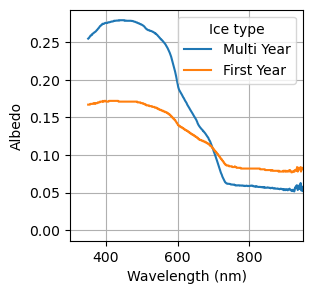

In [33]:
f, ax = plt.subplots(1, 1, figsize=(3, 3))

sns.lineplot(data=df_alb, x='wavelength', y='Albedo', hue='Ice type',
            ax=ax)

ax.set_xlabel('Wavelength (nm)')
ax.grid()
ax.set_xlim([300, 950])

f.savefig(os.path.join('..', 'figures', 'pcwg_fyi_v_myi.png'), bbox_inches='tight')

In [25]:
df_fyi

,Albedo,Ice type
wavelength,,
350,0.167,First Year
351,0.167,First Year
352,0.167,First Year
353,0.167,First Year
354,0.167,First Year
...,...,...
2424,NaN,First Year
2425,NaN,First Year
2426,NaN,First Year


<Axes: xlabel='wavelength'>

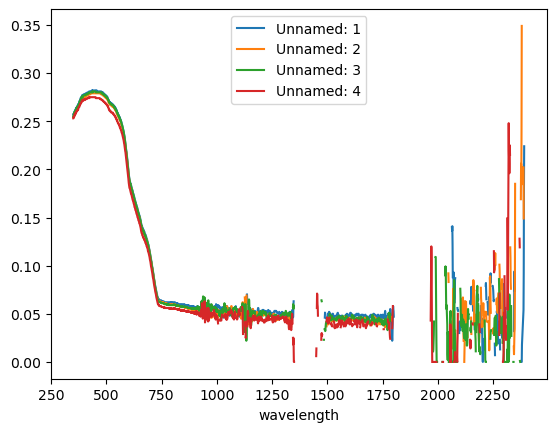

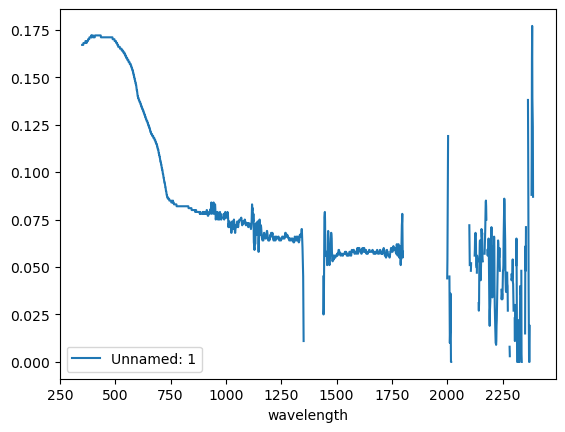

In [9]:
dict_in['spectral-contrasts-20250813-r2c'].plot()

dict_in['spectral-contrasts-20250810-r1c'].plot()